# Making Taste Legible: Corrected Results

This notebook is the presentation artifact for the publication-quality remediation. It reads tables generated by `analysis/`; authoritative computation occurs in the command-line modules and is covered by tests.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data'
FIGURES = ROOT / 'figures'
qa = json.loads((DATA / 'qa_corpus_summary.json').read_text())
cv = pd.read_csv(DATA / 'corrected_predictive_comparison.csv')
validation = pd.read_csv(DATA / 'corrected_independent_group_validation.csv')
vignettes = pd.read_csv(DATA / 'corrected_close_reading_vignettes.csv')
dimensions = pd.read_csv(DATA / 'w4_table6_dimension_projections.csv')
weat = pd.read_csv(DATA / 'w4_table7_weat_results.csv')
stability = json.loads((DATA / 'corrected_embedding_stability_summary.json').read_text())
print(f"Corpus: {qa['rows']:,} reviews; name-matched={qa['match_source']['name']['n']:,}; index-matched={qa['match_source']['index']['n']:,}")
print(f"Score: mean={qa['score']['mean']:.3f}; median={qa['score']['median']:.0f}")

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


FileNotFoundError: [Errno 2] No such file or directory: '/Users/mac/Desktop/CSSS594/FinalProject/data/corrected_predictive_comparison.csv'

## Corpus QA

Numeric score disclosures are removed from the primary modeling text before feature extraction. This cell displays the post-cleaning leakage checks.

In [ ]:
markers = pd.read_csv(DATA / 'qa_score_markers.csv')
post = markers[(markers.stage == 'analytical_text_after_cleaning') & (markers.scope == 'review_text')]
display(post[['marker', 'count']].reset_index(drop=True))
assert post['count'].sum() == 0

,marker,count
0,numeric_points,0
1,numeric_score_phrase,0
2,sgp_score_field,0
3,wf_score_field,0
4,score_label_numeric,0
5,numeric_score_label,0
6,personal_score_action,0
7,personal_percent_score,0
8,personal_score_sequence,0
9,numeric_in_tasting_book,0


## Out-of-Fold Prediction

All models use the same shuffled outer five-fold design. TF-IDF vectorization and Ridge tuning are fit inside training folds.

,model,evaluation,n,r2_oof,mae_oof,rmse_oof
0,M0: Baseline (length + year FE),out-of-fold 5-fold CV; random_state=42,11149,0.102,3.450,5.075
1,M1: VADER sentiment,out-of-fold 5-fold CV; random_state=42,11149,0.160,3.349,4.909
2,M2: Full dictionary (9 categories),out-of-fold 5-fold CV; random_state=42,11149,0.271,3.115,4.572
3,M3: Dictionary minus eval (8 categories),out-of-fold 5-fold CV; random_state=42,11149,0.246,3.195,4.650
4,"M4: TF-IDF / Ridge (5,000 features)",out-of-fold 5-fold CV; random_state=42,11149,0.590,2.148,3.429


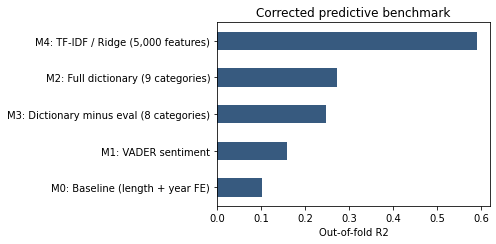

In [ ]:
display(cv.round(3))
plot_cv = cv.sort_values('r2_oof')
ax = plot_cv.plot.barh(x='model', y='r2_oof', legend=False, color='#375a7f', figsize=(7, 3.5))
ax.set_xlabel('Out-of-fold R2')
ax.set_ylabel('')
ax.set_title('Corrected predictive benchmark')
plt.tight_layout()
plt.show()

## Independent Validation

These groups are defined from assigned distillery or bottle-title cues, rather than from the dictionary feature rates they are used to validate.

In [ ]:
focus = validation[
    ((validation.group == 'Islay assigned distillery') & (validation.category == 'peat')) |
    ((validation.group == 'Sherry title cue') & (validation.category == 'sherry')) |
    ((validation.group == 'Bourbon title cue') & (validation.category == 'oak'))
]
display(focus[['group', 'category', 'n_group', 'group_mean_per1k', 'other_mean_per1k', 'cohen_d', 'welch_p']].round(3))
display(vignettes[['vignette', 'whisky_name_raw', 'category_rate_per1k', 'short_attributed_excerpt']].round(3))

,group,category,n_group,group_mean_per1k,other_mean_per1k,cohen_d,welch_p
1,Islay assigned distillery,peat,2374,24.175,6.543,1.333,0.000
11,Sherry title cue,sherry,2438,20.500,6.259,1.237,0.000
21,Bourbon title cue,oak,3436,7.131,7.378,-0.025,0.222


,vignette,whisky_name_raw,category_rate_per1k,short_attributed_excerpt
0,Criterion-association flaw case,"Glen Moray 12 yo 1989/2001 (46%, Signatory, sh...",77.67,"little unpleasant. Also some damp cardboard, n..."
1,Islay peated-style proxy case,"Laphroaig 13 yo 1998/2012 (59.0%, A D Rattray,...",126.05,"grassy smokiness. Then a grubby peat smoke, ..."
2,Sherry-title maturation case,"Longmorn 21 yo 1992/2014 (49.7%, The Single Ma...",95.89,"to the SigV, with prominent sherry, Mars ..."


## Corrected Embedding Evidence

Dimension projections use cosine similarity; category averages omit any word used to define the corresponding pole. The primary WEAT tests apply corrected permutation p-values and Holm adjustment.

In [ ]:
display(dimensions.round(3))
display(weat.round(4))
print(f"Natural/Artificial widest separation in {stability['natural_artificial_dominant_runs']} of {stability['runs']} prespecified stability runs.")

,category,Quality_Defect_proj,Quality_Defect_n,Complexity_Simplicity_proj,Complexity_Simplicity_n,Balance_Imbalance_proj,Balance_Imbalance_n,Natural_Artificial_proj,Natural_Artificial_n
0,fruit,0.041,42,0.058,42,0.044,42,-0.030,42
1,peat,0.083,36,-0.017,36,0.098,36,-0.069,36
2,sherry,0.054,33,0.089,33,0.029,33,-0.021,33
3,oak,-0.018,23,0.035,23,-0.029,23,-0.026,23
4,texture,0.043,30,-0.012,30,0.100,30,0.086,28
5,mineral,0.030,37,-0.100,37,0.008,37,-0.038,37
6,flaw,-0.161,27,-0.130,27,-0.214,27,-0.333,22
7,structure,0.033,32,-0.035,25,0.154,23,0.086,33
8,eval,0.162,9,-0.039,20,0.040,20,0.084,20


,test,effect_size_d,p_value_one_sided,n_permutations,X_terms,Y_terms,A_terms,B_terms,p_value_holm_primary,analysis_role
0,High vs low descriptors x quality/defect,1.6919,0.0006,3432,complex; waxy; tropical_fruit; balanced; elega...,thin; bitter; rubbery; cardboard; weak; dull; ...,excellent; superb; brilliant; marvellous; perf...,poor; flawed; disappointing; failed; unpleasant,0.0012,primary
1,Flaws vs neutral descriptors x defect/quality,0.9932,0.0344,1716,rubber; sulphur; cardboard; soap; metallic; fe...,barley; malt; cereal; apple; vanilla; honey,poor; flawed; dull; weak; disappointing,excellent; great; superb; brilliant; marvellous,0.0344,primary
2,Flaws vs neutral descriptors x defect/quality ...,1.0153,0.0432,924,rubber; cardboard; soap; metallic; feinty; sol...,barley; malt; cereal; apple; vanilla; honey,poor; flawed; dull; weak; disappointing,excellent; great; superb; brilliant; marvellous,NaN,sensitivity


Natural/Artificial widest separation in 30 of 30 prespecified stability runs.


## Interpretation

The corrected outputs support the narrower claim that domain vocabulary contains score-related structure missed by generic sentiment, while high-dimensional lexical models retain additional predictive information. Independent metadata checks validate several instrument categories. Claims about a dominant cultural embedding boundary depend on the recorded stability result and are stated conditionally in `paper/final_paper.md`.